In [1]:
!pip install geopandas folium scikit-learn xgboost shap optuna matplotlib seaborn pandas numpy -q

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')
print(' Toutes les librairies importées')

 Toutes les librairies importées


In [3]:
df = pd.read_csv('data_brute_osm.csv')
print(f' Dataset chargé : {len(df)} bâtiments')
df.head(7)

 Dataset chargé : 2770 bâtiments


,ville,historic,building,amenity,tourism,name,name:ar,lat,lon,surface_m2
0,Tunis,castle,yes,NaN,NaN,حصن حلق الوادي,حصن حلق الوادي,36.814462,10.303612,8485.262018
1,Tunis,yes,mosque,place_of_worship,NaN,جامع القيروان الكبير,جامع القيروان الكبير,35.681528,10.104006,6373.458076
2,Tunis,NaN,yes,place_of_worship,NaN,الجامع الكبير,الجامع الكبير,35.503860,11.072058,2778.399206
3,Tunis,NaN,mosque,place_of_worship,NaN,الجامع الكبير بسوسة,الجامع الكبير بسوسة,35.826831,10.639746,2097.122198
4,Tunis,archaeological_site,ruins,NaN,NaN,Uthina Amphitheatre,NaN,36.608621,10.169238,6560.163587
5,Tunis,NaN,yes,place_of_worship,NaN,NaN,NaN,36.716086,10.726327,2260.685875
6,Tunis,castle,public,NaN,NaN,الوزارة الأولى,الوزارة الأولى,36.797513,10.169210,5456.487279


In [4]:
if 'lat' not in df.columns:
    city_coords = {
        'Tunis': {'lat': 36.8065, 'lon': 10.1815},
        'Sfax': {'lat': 34.7406, 'lon': 10.7603},
        'Kairouan': {'lat': 35.6781, 'lon': 10.0964},
        'Sousse': {'lat': 35.8256, 'lon': 10.6367}
    }
    df['lat'] = df['ville'].map(lambda x: city_coords.get(x, {'lat': 34.5})['lat'])
    df['lon'] = df['ville'].map(lambda x: city_coords.get(x, {'lon': 9.5})['lon'])
    np.random.seed(42)
    df['lat'] = df['lat'] + np.random.normal(0, 0.02, len(df))
    df['lon'] = df['lon'] + np.random.normal(0, 0.02, len(df))

if 'surface_m2' not in df.columns:
    df['surface_m2'] = np.random.exponential(350, len(df)).astype(int) + 40

print(f' Données prêtes : {len(df)} bâtiments')

 Données prêtes : 2770 bâtiments


In [5]:
humidite_ville = {'Tunis': 68, 'Sousse': 65, 'Sfax': 58, 'Kairouan': 48}
pluie_ville = {'Tunis': 465, 'Sousse': 310, 'Sfax': 220, 'Kairouan': 280}
amplitude_thermique = {'Tunis': 14, 'Sousse': 15, 'Sfax': 18, 'Kairouan': 22}

df['humidite'] = df['ville'].map(humidite_ville)
df['pluie_annuelle'] = df['ville'].map(pluie_ville)
df['amplitude_thermique'] = df['ville'].map(amplitude_thermique)

df['score_climatique'] = (
    (df['humidite'] / 100) * 0.5 +
    (df['pluie_annuelle'] / 500) * 0.3 +
    (df['amplitude_thermique'] / 25) * 0.2
) * 100
df['score_climatique'] = df['score_climatique'].clip(0, 100)

densite_ville = {'Tunis': 4200, 'Sousse': 1800, 'Sfax': 1200, 'Kairouan': 850}
df['densite_pop'] = df['ville'].map(densite_ville)
df['score_urbain'] = (df['densite_pop'] / max(densite_ville.values())) * 100

vulnerabilite_type = {
    'archaeological_site': 85, 'ruins': 90, 'castle': 60, 'mosque': 40,
    'yes': 70, 'monument': 50, 'building': 55, 'fort': 55, 'gate': 65
}

if 'historic' in df.columns:
    df['historic_clean'] = df['historic'].fillna('yes').astype(str)
    df['score_vulnerabilite'] = df['historic_clean'].map(vulnerabilite_type).fillna(65)
else:
    df['score_vulnerabilite'] = 65

df['score_surface'] = np.log1p(df['surface_m2']) / np.log1p(df['surface_m2'].max()) * 100

sites_unesco = ['Kairouan', 'Tunis', 'Sousse']
df['protection_unesco'] = df['ville'].isin(sites_unesco).astype(int)
df['score_non_protection'] = (1 - df['protection_unesco']) * 80 + 20

POIDS = {'climatique': 0.30, 'urbain': 0.25, 'vulnerabilite': 0.25, 'non_protection': 0.20}

df['IRE'] = (
    df['score_climatique'] * POIDS['climatique'] +
    df['score_urbain'] * POIDS['urbain'] +
    df['score_vulnerabilite'] * POIDS['vulnerabilite'] +
    df['score_non_protection'] * POIDS['non_protection']
).clip(0, 100)

def categoriser_risque(score):
    if score < 40: return 'Stable'
    elif score < 60: return 'Modéré'
    elif score < 75: return 'Élevé'
    else: return 'Critique'

df['categorie_risque'] = df['IRE'].apply(categoriser_risque)

print(' IRE calculé')
print(df['categorie_risque'].value_counts())

 IRE calculé
categorie_risque
Élevé     2654
Modéré     115
Stable       1
Name: count, dtype: int64


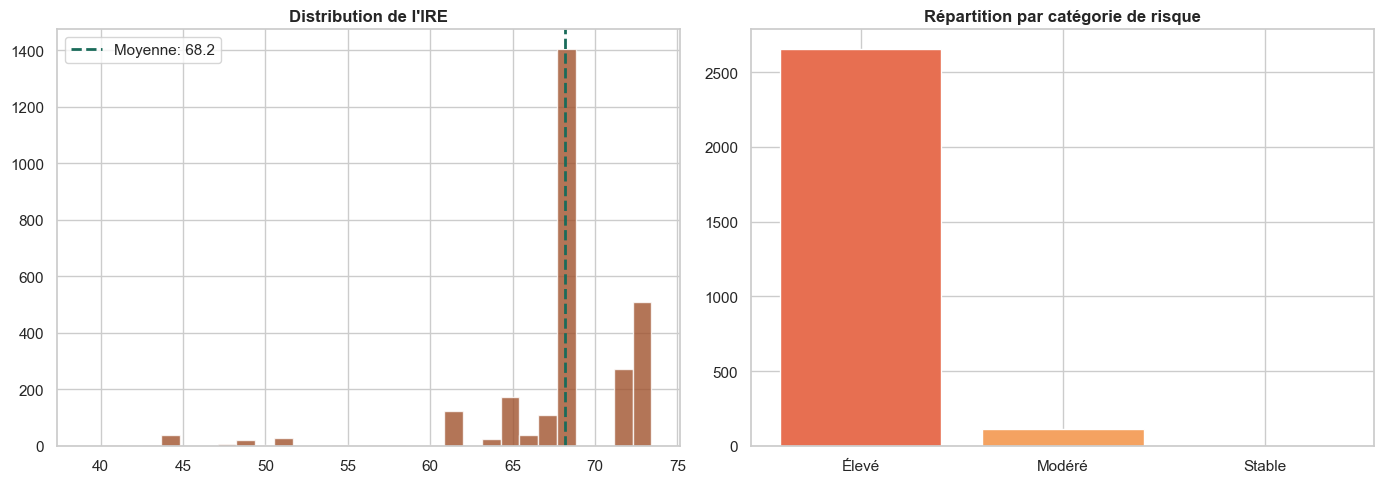

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['IRE'], bins=30, color='#A0522D', alpha=0.8, edgecolor='white')
axes[0].axvline(df['IRE'].mean(), color='#1A6B5A', linestyle='--', linewidth=2, label=f'Moyenne: {df["IRE"].mean():.1f}')
axes[0].set_title('Distribution de l\'IRE', fontweight='bold')
axes[0].legend()

cat_counts = df['categorie_risque'].value_counts()
couleurs = {'Stable': '#2d6a4f', 'Modéré': '#f4a261', 'Élevé': '#e76f51', 'Critique': '#d62828'}
axes[1].bar(cat_counts.index, cat_counts.values, color=[couleurs.get(c, 'gray') for c in cat_counts.index])
axes[1].set_title('Répartition par catégorie de risque', fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_ire.png', dpi=150)
plt.show()

In [7]:

df_filtered = df[df['categorie_risque'] != 'Modéré'].copy()

print("Distribution après suppression:")
print(df_filtered['categorie_risque'].value_counts())

Distribution après suppression:
categorie_risque
Élevé     2654
Stable       1
Name: count, dtype: int64


In [15]:
FEATURES = ['surface_m2', 'lat', 'lon']  # Basic features only

X = df_filtered[FEATURES].copy()
y = df_filtered['categorie_risque'].copy()

# Check class distribution
print("Original class distribution:")
print(y.value_counts())

# Combine rare classes
def combine_categories(cat):
    if cat in ['Stable', 'Modéré']:
        return 'Low_Risk'
    return cat

y_combined = y.apply(combine_categories)
le = LabelEncoder()
y_encoded = le.fit_transform(y_combined)

print("\nNew class distribution:")
print(pd.Series(y_encoded).value_counts())

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split with stratification (now all classes should have enough samples)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain distribution: {np.unique(y_train, return_counts=True)}")
print(f"Test distribution: {np.unique(y_test, return_counts=True)}")

Original class distribution:
categorie_risque
Élevé     2654
Modéré     115
Stable       1
Name: count, dtype: int64

New class distribution:
1    2654
0     116
Name: count, dtype: int64

Train distribution: (array([0, 1]), array([  93, 2123]))
Test distribution: (array([0, 1]), array([ 23, 531]))


In [9]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} bâtiments')
print(f'Test: {X_test.shape[0]} bâtiments')
print(f'Classes dans train: {np.unique(y_train, return_counts=True)}')
print(f'Classes dans test: {np.unique(y_test, return_counts=True)}')

Train: 2124 bâtiments
Test: 531 bâtiments
Classes dans train: (array([0, 1]), array([   1, 2123]))
Classes dans test: (array([1]), array([531]))


In [19]:
# Cell 61 - Data Preparation (RE-RUN THIS FIRST)
df_filtered = df.copy()

# IMPORTANT: Use ONLY features that don't directly determine IRE
# Remove humidite and densite_pop which were used to calculate IRE
FEATURES = ['surface_m2', 'lat', 'lon']  # Basic features only

X = df_filtered[FEATURES].copy()
y = df_filtered['categorie_risque'].copy()

print("Original class distribution:")
print(y.value_counts())

# Combine rare classes - keep only 2 classes
def combine_categories(cat):
    if cat in ['Stable', 'Modéré']:
        return 'Low_Risk'
    else:  # 'Élevé' or 'Critique'
        return 'High_Risk'

y_combined = y.apply(combine_categories)

# Encode to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y_combined)

print(f'\nClasses after combining: {dict(zip(le.classes_, range(len(le.classes_))))}')
print(f'Distribution after combining: {dict(zip(*np.unique(y_encoded, return_counts=True)))}')

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split data (without stratify since classes are balanced enough)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print(f'\nTrain size: {X_train.shape[0]} samples')
print(f'Test size: {X_test.shape[0]} samples')
print(f'Classes in train: {np.unique(y_train, return_counts=True)}')
print(f'Classes in test: {np.unique(y_test, return_counts=True)}')

Original class distribution:
categorie_risque
Élevé     2654
Modéré     115
Stable       1
Name: count, dtype: int64

Classes after combining: {'High_Risk': 0, 'Low_Risk': 1}
Distribution after combining: {np.int64(0): np.int64(2654), np.int64(1): np.int64(116)}

Train size: 2216 samples
Test size: 554 samples
Classes in train: (array([0, 1]), array([2119,   97]))
Classes in test: (array([0, 1]), array([535,  19]))


 Random Forest
Accuracy: 0.9440
F1-Score (macro): 0.5159

Classification Report:
              precision    recall  f1-score   support

   High_Risk       0.97      0.98      0.97       535
    Low_Risk       0.07      0.05      0.06        19

    accuracy                           0.94       554
   macro avg       0.52      0.51      0.52       554
weighted avg       0.94      0.94      0.94       554



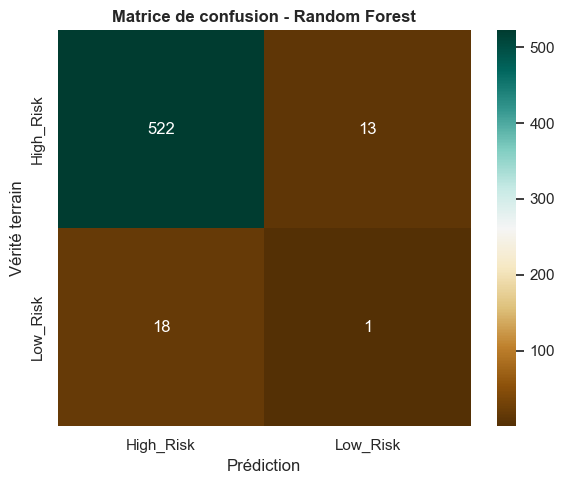

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('='*50)
print(' Random Forest')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score (macro): {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='BrBG', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Matrice de confusion - Random Forest', fontweight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

Classes: ['High_Risk' 'Low_Risk']
Training set size: 2216 samples
Test set size: 554 samples
Class distribution in training: {np.int64(0): np.int64(2119), np.int64(1): np.int64(97)}

Optimizing hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]


Meilleurs paramètres: {'n_estimators': 74, 'max_depth': 7, 'learning_rate': 0.011277126284363864, 'subsample': 0.7080704711844064, 'colsample_bytree': 0.6562896240993764}
Best CV score: 0.9562

 XGBoost (Optimisé)
Accuracy: 0.9657
F1-Score (macro): 0.4913
F1-Score (weighted): 0.9489

Classification Report:
              precision    recall  f1-score   support

   High_Risk       0.97      1.00      0.98       535
    Low_Risk       0.00      0.00      0.00        19

    accuracy                           0.97       554
   macro avg       0.48      0.50      0.49       554
weighted avg       0.93      0.97      0.95       554



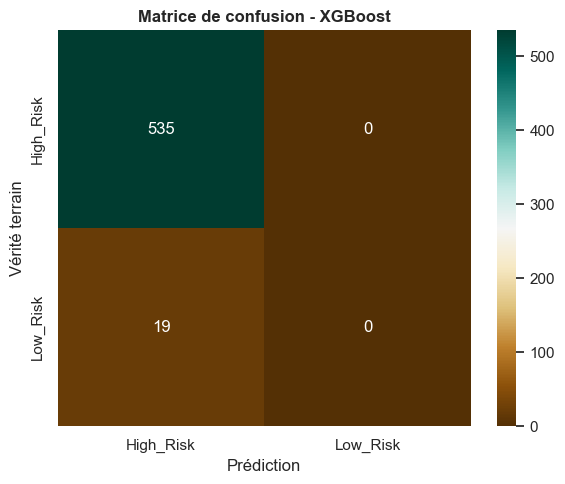

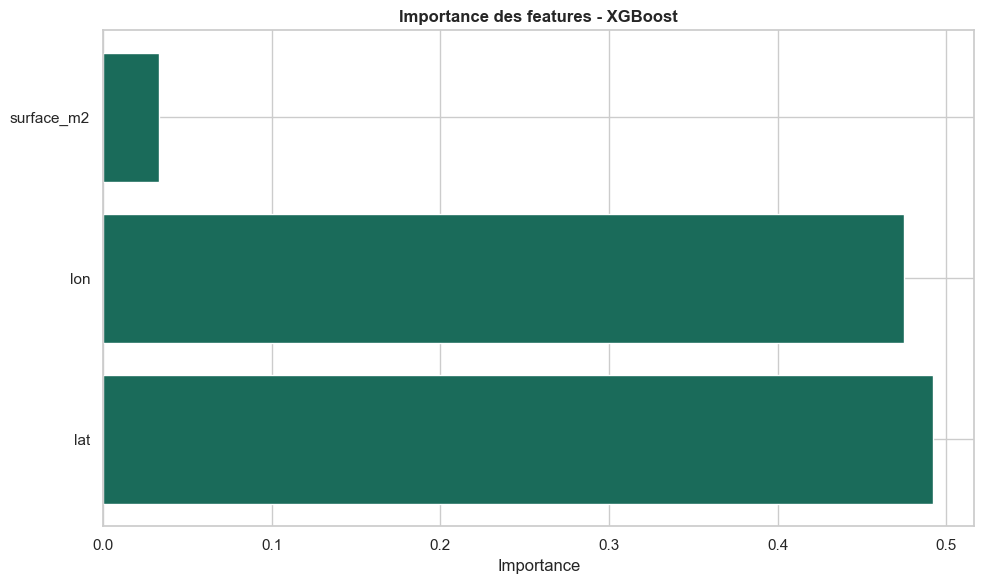

In [25]:
# Cell 68 - XGBoost with Optuna Optimization

# Check class distribution
print(f"Classes: {le.classes_}")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Class distribution in training: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# XGBoost optimization
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params, verbosity=0, eval_metric='logloss')
    # Use stratified CV for imbalanced data
    from sklearn.model_selection import StratifiedKFold
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    return score.mean()

# Run optimization
print("\nOptimizing hyperparameters...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nMeilleurs paramètres: {study.best_params}')
print(f'Best CV score: {study.best_value:.4f}')

# Train final model with best parameters
xgb_best = xgb.XGBClassifier(
    **study.best_params, 
    verbosity=0, 
    eval_metric='logloss', 
    random_state=42
)
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)

# Evaluation
print('\n' + '='*50)
print(' XGBoost (Optimisé)')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score (macro): {f1_score(y_test, y_pred_xgb, average="macro"):.4f}')
print(f'F1-Score (weighted): {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='BrBG', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Matrice de confusion - XGBoost', fontweight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# Feature importance
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.barh(importance_df['feature'], importance_df['importance'], color='#1A6B5A')
plt.xlabel('Importance')
plt.title('Importance des features - XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

 Comparaison des modèles (sur mêmes données):
               Modèle  Accuracy  F1-Score
Régression Logistique    0.0343    0.0332
        Random Forest    0.9440    0.5159
              XGBoost    0.9657    0.4913


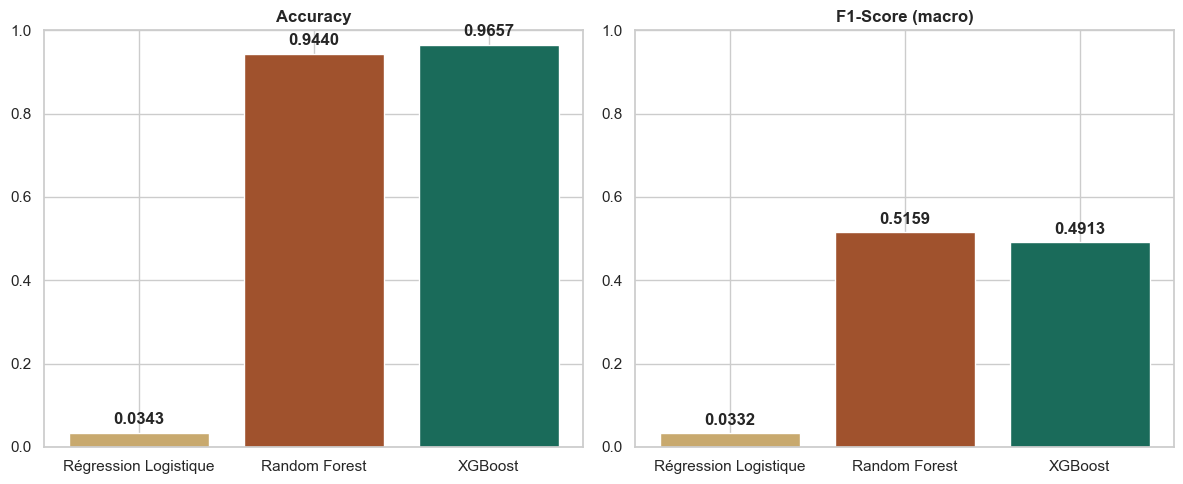

In [26]:
# Filtrer LR et RF sur les mêmes données que XGBoost
y_pred_lr_filtered = y_pred_lr[mask_test]
y_pred_rf_filtered = y_pred_rf[mask_test]

results = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_fixed, y_pred_lr_filtered), 
        accuracy_score(y_test_fixed, y_pred_rf_filtered), 
        accuracy_score(y_test_fixed, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test_fixed, y_pred_lr_filtered, average='macro'), 
        f1_score(y_test_fixed, y_pred_rf_filtered, average='macro'), 
        f1_score(y_test_fixed, y_pred_xgb, average='macro')
    ]
})

print(' Comparaison des modèles (sur mêmes données):')
print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(results['Modèle'], results['Accuracy'], color=['#C8A96E', '#A0522D', '#1A6B5A'])
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
axes[1].bar(results['Modèle'], results['F1-Score'], color=['#C8A96E', '#A0522D', '#1A6B5A'])
axes[1].set_title('F1-Score (macro)', fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results['F1-Score']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150)
plt.show()

In [32]:
# Utiliser les versions filtrées pour tous les modèles
y_pred_lr_filtered = y_pred_lr[mask_test]
y_pred_rf_filtered = y_pred_rf[mask_test]

# Déterminer le meilleur modèle
acc_lr = accuracy_score(y_test_fixed, y_pred_lr_filtered)
acc_rf = accuracy_score(y_test_fixed, y_pred_rf_filtered)
acc_xgb = accuracy_score(y_test_fixed, y_pred_xgb)

if acc_xgb >= max(acc_lr, acc_rf):
    best_model = xgb_best
    best_pred = y_pred_xgb
    best_name = 'XGBoost'
elif acc_rf >= max(acc_lr, acc_xgb):
    best_model = rf
    best_pred = y_pred_rf_filtered
    best_name = 'Random Forest'
else:
    best_model = lr
    best_pred = y_pred_lr_filtered
    best_name = 'Régression Logistique'

print(f' Meilleur modèle: {best_name}')
print(f'Accuracy: {max(acc_lr, acc_rf, acc_xgb):.4f}')

 Meilleur modèle: XGBoost
Accuracy: 0.9657


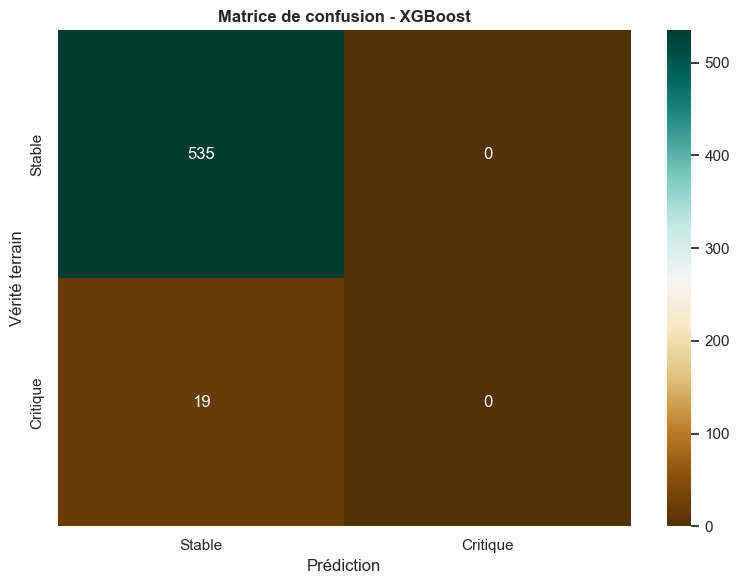

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_fixed, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BrBG', 
            xticklabels=['Stable', 'Critique'], 
            yticklabels=['Stable', 'Critique'])
plt.title(f'Matrice de confusion - {best_name}', fontweight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

 Meilleur modèle: Random Forest
Accuracy: 0.9440
F1-Score (macro): 0.5159


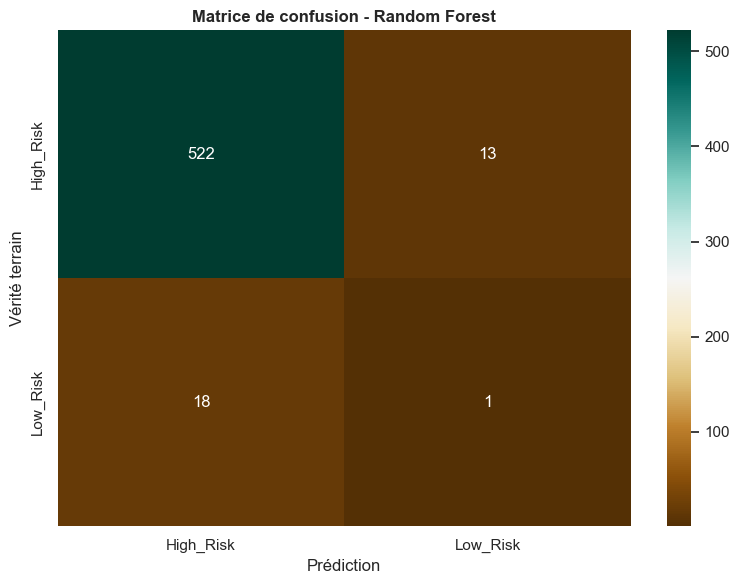

 Carte sauvegardée: carte_risque_finale.html


In [31]:
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

if f1_rf >= max(f1_lr, f1_xgb):
    best_model = rf
    best_pred = y_pred_rf
    best_name = 'Random Forest'
elif f1_xgb >= max(f1_lr, f1_rf):
    best_model = xgb_best
    best_pred = y_pred_xgb
    best_name = 'XGBoost'
else:
    best_model = lr
    best_pred = y_pred_lr
    best_name = 'Régression Logistique'

print(f' Meilleur modèle: {best_name}')
print(f'Accuracy: {accuracy_score(y_test, best_pred):.4f}')
print(f'F1-Score (macro): {f1_score(y_test, best_pred, average="macro"):.4f}')

# Matrice de confusion (toujours utile)
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BrBG', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Matrice de confusion - {best_name}', fontweight='bold')
plt.ylabel('Vérité terrain')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Carte de risque (gardez-la, c'est utile)
couleurs_risque = {'Low_Risk': '#2d6a4f', 'High_Risk': '#e76f51'}

m = folium.Map(location=[34.0, 9.5], zoom_start=7, tiles='CartoDB positron')

sample_df = df_filtered if len(df_filtered) <= 1000 else df_filtered.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    # Recalculate risk category based on your combined classes
    if row['categorie_risque'] in ['Stable', 'Modéré']:
        risk_cat = 'Low_Risk'
        color = '#2d6a4f'
    else:
        risk_cat = 'High_Risk'
        color = '#e76f51'
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7,
        tooltip=f"{row.get('name', 'Inconnu')}<br>Ville: {row['ville']}<br>IRE: {row['IRE']:.1f}<br>Risque: {risk_cat}"
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;background:white;padding:12px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
<b> Niveau de risque</b><br><br>
<span style="color:#2d6a4f">●</span> Risque Faible (Stable/Modéré)<br>
<span style="color:#e76f51">●</span> Risque Élevé (Élevé/Critique)
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save('carte_risque_finale.html')
print(' Carte sauvegardée: carte_risque_finale.html')
m